# NLP-модель успешности Product Hunt

В этой части проекта я решаю задачу бинарной классификации для запусков Product Hunt: по текстовому описанию продукта (`description`) нужно предсказать, попадет ли запуск в успешные (`successful_launch`).

В качестве признаков я использую только описание продукта, потому что мой критерий отвечает именно за работу с неструктурированными текстовыми данными. Для сравнения беру сильный классический baseline на TF-IDF и три нейросетевые архитектуры: Embedding Pooling, TextCNN и BiLSTM. Метрики и артефакты экспериментов логируются в W&B, а также сохраняются в Google Drive.


## 0. Подключение Google Drive

Датасет и результаты экспериментов лежат на Google Drive, поэтому в Colab сначала подключаю диск. Так выходные файлы, веса моделей и таблицы с метриками сохраняются после завершения сессии.


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass


Mounted at /content/drive


## 1. Импорты, пути и настройки

Здесь собраны основные библиотеки и параметры эксперимента: путь к данным, папка для результатов, выбранная текстовая колонка, ограничения словаря и длины последовательности, параметры обучения и настройки W&B. Отдельно фиксирую `seed`, чтобы результаты были воспроизводимыми при повторном запуске.


In [3]:
!pip install wandb

In [5]:
import wandb
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ainikitadanik (ainikitadanik-hse) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
import os
import re
import json
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.style.use('ggplot')


class CFG:
    seed = 42
    data_path = '/content/drive/MyDrive/GP5/product_hunt_processed_with_splits.csv'
    output_dir = '/content/drive/MyDrive/GP5/criterion4_outputs'
    text_col = 'description'
    max_vocab_size = 20000
    min_freq = 2
    max_len = 96
    batch_size = 32
    epochs = 8
    lr = 1e-3
    weight_decay = 1e-4
    embed_dim = 128
    hidden_dim = 128
    dropout = 0.35
    use_wandb = True
    wandb_project = 'gp5-product-hunt-nlp'
    wandb_entity = None
    wandb_group = 'criterion4-description-only'


SUCCESS_WEIGHTS = {
    'votes_score': 0.50,
    'comments_score': 0.20,
    'reviews_score': 0.10,
    'collections_score': 0.10,
    'rank_score': 0.10,
}

OUTPUT_DIR = Path(CFG.output_dir)
ARTIFACT_DIR = OUTPUT_DIR / 'artifacts'
RESULTS_DIR = OUTPUT_DIR / 'results'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(CFG.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('output_dir:', OUTPUT_DIR)


device: cuda
output_dir: /content/drive/MyDrive/GP5/criterion4_outputs


## 2. Загрузка данных

Загружаю подготовленный командой датасет и оставляю для первичного просмотра ключевые колонки: описание продукта, продуктовые метрики, рассчитанный `success_score`, готовый бинарный таргет и разбиение на выборки.


In [7]:
candidate_paths = [
    CFG.data_path,
    '/content/product_hunt_processed_with_splits.csv',
    '/content/drive/MyDrive/GP5/product_hunt_processed_with_splits.csv',
    '/Users/a1/Downloads/product_hunt_processed_with_splits.csv',
]

data_path = next((path for path in candidate_paths if os.path.exists(path)), None)
if data_path is None:
    raise FileNotFoundError('Не найден product_hunt_processed_with_splits.csv. Укажите путь в CFG.data_path.')

usecols = [
    'name', 'tagline', 'description',
    'votesCount', 'commentsCount', 'reviewsCount', 'collections_totalCount',
    'dailyRank', 'weeklyRank', 'monthlyRank',
    'success_score', 'successful_launch', 'split',
]

df_raw = pd.read_csv(data_path, encoding='utf-8-sig', usecols=usecols)
print(data_path)
print(df_raw.shape)
df_raw.head(3)


/content/drive/MyDrive/GP5/product_hunt_processed_with_splits.csv
(158583, 13)


,name,tagline,description,votesCount,commentsCount,reviewsCount,dailyRank,weeklyRank,monthlyRank,collections_totalCount,success_score,successful_launch,split
0,adyoutiser,Self-service marketplace for digital out-of-ho...,adyoutiser is the self-service marketplace for...,4,1,0,115.0,258.0,NaN,0,0.541763,0,train
1,Knock agent for Slack,"Build, manage, and ship customer messaging fro...",Knock is the agent-led customer engagement pla...,98,7,3,13.0,28.0,25.0,1,0.959509,1,train
2,Co-Invest,Trade 500+ markets directly from ChatGPT & Claude,Co-Invest by Liquid lets you research and plac...,229,37,0,4.0,10.0,30.0,13,0.936733,1,valid


## 3. Готовый target и split

В финальном датасете уже есть командно согласованный `success_score`, бинарный признак `successful_launch` и колонка `split`. Поэтому я не пересчитываю целевую переменную и не создаю новое случайное разбиение, а использую ровно те train, valid и test, которые подготовлены для общего проекта.


In [8]:
df = df_raw.copy()
df['text'] = df[CFG.text_col].fillna('').astype(str).str.strip()
df['target'] = pd.to_numeric(df['successful_launch'], errors='coerce')
df['success_score'] = pd.to_numeric(df['success_score'], errors='coerce')
df['split'] = df['split'].astype(str).str.lower().str.strip()

df = df[df['text'].str.len() > 0].copy()
df = df[df['target'].isin([0, 1])].copy()
df = df[df['split'].isin(['train', 'valid', 'test'])].copy()
df['target'] = df['target'].astype(int)

print('Rows:', len(df))
print('Text column:', CFG.text_col)
print('Split counts:')
print(df['split'].value_counts().to_string())
print()
print('Target share by split:')
print(pd.crosstab(df['split'], df['target'], normalize='index').round(4))

df[['description', 'votesCount', 'commentsCount', 'reviewsCount', 'collections_totalCount',
    'dailyRank', 'weeklyRank', 'monthlyRank', 'success_score', 'target', 'split']].head()

Rows: 158581
Text column: description
Split counts:
split
train    101490
test      31717
valid     25374

Target share by split:
target    0    1
split           
test    0.8  0.2
train   0.8  0.2
valid   0.8  0.2


,description,votesCount,commentsCount,reviewsCount,collections_totalCount,dailyRank,weeklyRank,monthlyRank,success_score,target,split
0,adyoutiser is the self-service marketplace for...,4,1,0,0,115.0,258.0,NaN,0.541763,0,train
1,Knock is the agent-led customer engagement pla...,98,7,3,1,13.0,28.0,25.0,0.959509,1,train
2,Co-Invest by Liquid lets you research and plac...,229,37,0,13,4.0,10.0,30.0,0.936733,1,valid
3,Auto-renewals creep up. Contracts pile up in i...,4,1,0,0,115.0,258.0,778.0,0.544073,0,train
4,"ForgeSpy tells you if an image, video, or voic...",3,1,0,0,580.0,972.0,NaN,0.486692,0,test


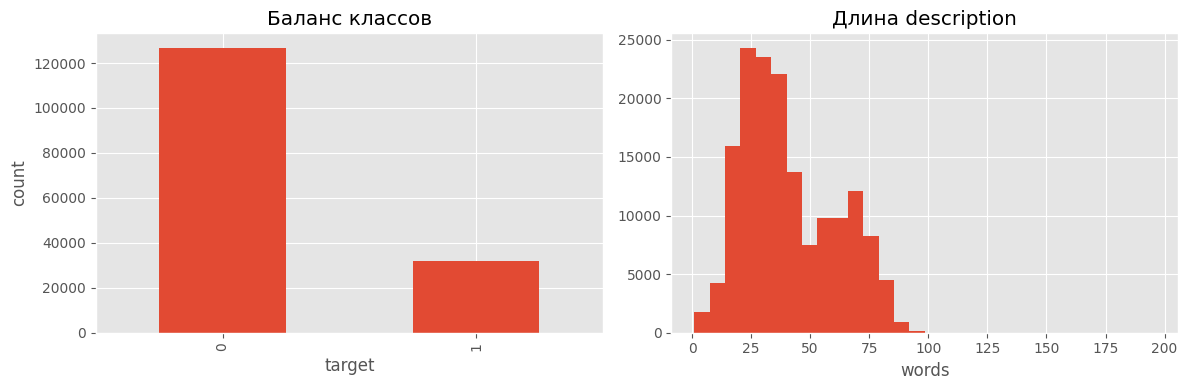

In [9]:
df['text_len_words'] = df['text'].str.split().map(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['target'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Баланс классов')
axes[0].set_xlabel('target')
axes[0].set_ylabel('count')
df['text_len_words'].hist(bins=30, ax=axes[1])
axes[1].set_title('Длина description')
axes[1].set_xlabel('words')
plt.tight_layout()

## 4. Train / valid / test

Разделяю данные по колонке `split` и проверяю баланс классов. Во всех трех частях сохраняется соотношение примерно 80/20, поэтому accuracy сама по себе не очень показательна: дополнительно важно смотреть F1, precision, recall и ROC-AUC.


In [10]:
train_df = df[df['split'] == 'train'].copy()
valid_df = df[df['split'] == 'valid'].copy()
test_df = df[df['split'] == 'test'].copy()

for name, part in [('train', train_df), ('valid', valid_df), ('test', test_df)]:
    print(name, part.shape, part['target'].value_counts(normalize=True).to_dict())

train (101490, 16) {0: 0.8, 1: 0.2}
valid (25374, 16) {0: 0.799992117915977, 1: 0.200007882084023}
test (31717, 16) {0: 0.8000126115332472, 1: 0.19998738846675285}


## 5. Метрики

Для всех моделей использую одинаковый расчет качества. Основной ориентир для сравнения - F1, потому что классы несбалансированы и важно учитывать одновременно precision и recall. Порог классификации подбираю на validation по F1, а затем с тем же порогом считаю качество на test.


In [11]:
def get_metrics(y_true, y_pred, y_proba=None):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None and len(np.unique(y_true)) == 2:
        metrics['roc_auc'] = roc_auc_score(y_true, y_proba)
    else:
        metrics['roc_auc'] = np.nan
    return metrics


def best_f1_threshold(y_true, y_proba):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = [f1_score(y_true, y_proba >= t, zero_division=0) for t in thresholds]
    return float(thresholds[int(np.argmax(scores))])


def metrics_at_threshold(y_true, y_proba, threshold):
    y_pred = (np.asarray(y_proba) >= threshold).astype(int)
    out = get_metrics(y_true, y_pred, y_proba)
    out['threshold'] = threshold
    return out


results = []
model_runs = []


## 6. Токенизация и DataLoader

Для нейросетевых моделей перевожу описания в последовательности индексов слов. Словарь строится только по train, редкие слова отсекаются, а последовательности приводятся к одной длине через padding/truncation. Это стандартная подготовка текста для Embedding, CNN и LSTM моделей.


In [12]:
TOKEN_RE = re.compile(r"(?u)\b\w[\w+'-]*\b")


def tokenize(text):
    return TOKEN_RE.findall(str(text).lower())


from collections import Counter

counter = Counter()
for text in train_df['text']:
    counter.update(tokenize(text))

itos = ['<pad>', '<unk>']
for token, freq in counter.most_common(CFG.max_vocab_size - 2):
    if freq >= CFG.min_freq:
        itos.append(token)

stoi = {token: i for i, token in enumerate(itos)}
pad_idx = stoi['<pad>']
unk_idx = stoi['<unk>']


def encode_text(text):
    ids = [stoi.get(token, unk_idx) for token in tokenize(text)]
    if not ids:
        ids = [unk_idx]
    length = min(len(ids), CFG.max_len)
    ids = ids[:CFG.max_len]
    ids = ids + [pad_idx] * (CFG.max_len - len(ids))
    return ids, length


print('Vocab size:', len(itos))
print(counter.most_common(20))


Vocab size: 20000
[('and', 172071), ('a', 81274), ('your', 77022), ('to', 71466), ('for', 64807), ('the', 62678), ('with', 56644), ('you', 44562), ('in', 44359), ('is', 42633), ('ai', 41532), ('no', 35903), ('it', 29018), ('that', 26487), ('of', 26284), ('on', 24154), ('or', 24110), ('free', 21131), ('from', 17015), ('built', 16578)]


In [13]:
class ProductHuntDataset(Dataset):
    def __init__(self, frame):
        self.texts = frame['text'].tolist()
        self.targets = frame['target'].astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids, length = encode_text(self.texts[idx])
        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'length': torch.tensor(length, dtype=torch.long),
            'target': torch.tensor(self.targets[idx], dtype=torch.float32),
        }


def make_loader(frame, shuffle=False):
    return DataLoader(ProductHuntDataset(frame), batch_size=CFG.batch_size, shuffle=shuffle, num_workers=0)


train_loader = make_loader(train_df, True)
valid_loader = make_loader(valid_df, False)
test_loader = make_loader(test_df, False)

next(iter(train_loader))

{'input_ids': tensor([[3305, 4704,  131,  ...,    0,    0,    0],
         [   1,   11,    3,  ...,    0,    0,    0],
         [   1,  121,    9,  ...,    0,    0,    0],
         ...,
         [  75,  243,   23,  ...,    0,    0,    0],
         [ 173, 1023,    3,  ...,    0,    0,    0],
         [   1,   11,   23,  ...,    0,    0,    0]]),
 'length': tensor([30, 53, 67,  8, 35, 11, 20, 80, 28, 31, 28, 66, 23, 20, 20, 34, 31, 27,
         75, 68, 30, 32, 40, 71, 18, 27, 68, 42, 25, 85, 17, 39]),
 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
         0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0.])}

## 7. Архитектуры моделей

В работе сравниваю три нейросетевых подхода из тем курса. Первая модель усредняет и агрегирует эмбеддинги слов, вторая ищет локальные шаблоны через одномерные свертки, третья обрабатывает описание как последовательность с помощью BiLSTM.


In [14]:
class EmbeddingPoolingClassifier(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, CFG.embed_dim, padding_idx=pad_idx)
        self.classifier = nn.Sequential(
            nn.Linear(CFG.embed_dim * 2, CFG.hidden_dim),
            nn.ReLU(),
            nn.Dropout(CFG.dropout),
            nn.Linear(CFG.hidden_dim, 1),
        )

    def forward(self, input_ids, lengths=None):
        emb = self.embedding(input_ids)
        mask = (input_ids != pad_idx).unsqueeze(-1)
        mean_pool = (emb * mask).sum(1) / mask.sum(1).clamp(min=1)
        max_pool = emb.masked_fill(~mask, -1e9).max(1).values
        x = torch.cat([mean_pool, max_pool], dim=1)
        return self.classifier(x).squeeze(1)


class TextCNNClassifier(nn.Module):
    def __init__(self, vocab_size, num_filters=64, kernel_sizes=(2, 3, 4, 5)):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, CFG.embed_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(CFG.embed_dim, num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(CFG.dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, input_ids, lengths=None):
        x = self.embedding(input_ids).transpose(1, 2)
        features = []
        for conv in self.convs:
            conv_out = torch.relu(conv(x))
            features.append(conv_out.max(2).values)
        x = torch.cat(features, dim=1)
        x = self.dropout(x)
        return self.fc(x).squeeze(1)


class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, CFG.embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=CFG.embed_dim,
            hidden_size=CFG.hidden_dim,
            batch_first=True,
            bidirectional=True,
            num_layers=2,
            dropout=CFG.dropout,
        )
        self.dropout = nn.Dropout(CFG.dropout)
        self.fc1 = nn.Linear(CFG.hidden_dim * 2, CFG.hidden_dim)
        self.fc2 = nn.Linear(CFG.hidden_dim, 1)

    def forward(self, input_ids, lengths):
        emb = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb,
            lengths.detach().cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)
        x = torch.cat([hidden[-2], hidden[-1]], dim=1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x).squeeze(1)

## 8. Цикл обучения

В этом блоке вынесена общая логика обучения PyTorch-моделей: проход по эпохам, расчет loss, оценка на validation, подбор лучшего порога, сохранение весов и логирование метрик. Один и тот же цикл используется для всех трех нейросетевых экспериментов, чтобы сравнение было честным.


In [15]:
try:
    import wandb
except Exception:
    wandb = None


def clean_name(name):
    return name.lower().replace(' ', '_').replace('+', 'plus').replace('-', '_')


def cfg_dict():
    return {
        'seed': CFG.seed,
        'data_path': data_path,
        'text_col': CFG.text_col,
        'max_vocab_size': CFG.max_vocab_size,
        'min_freq': CFG.min_freq,
        'max_len': CFG.max_len,
        'batch_size': CFG.batch_size,
        'epochs': CFG.epochs,
        'lr': CFG.lr,
        'weight_decay': CFG.weight_decay,
        'embed_dim': CFG.embed_dim,
        'hidden_dim': CFG.hidden_dim,
        'dropout': CFG.dropout,
        'device': str(device),
        'train_rows': len(train_df),
        'valid_rows': len(valid_df),
        'test_rows': len(test_df),
        'target': 'successful_launch',
        'vocab_size': len(itos),
    }


def start_wandb_run(model_name, params):
    if not CFG.use_wandb:
        return None
    if wandb is None:
        raise ImportError('wandb не установлен. В Colab выполните: !pip install wandb')

    config = cfg_dict()
    config.update(params)
    return wandb.init(
        project=CFG.wandb_project,
        entity=CFG.wandb_entity,
        group=CFG.wandb_group,
        name=model_name,
        config=config,
        reinit=True,
    )


def log_wandb_artifact(run, path, artifact_name, artifact_type):
    if run is None:
        return
    artifact = wandb.Artifact(artifact_name, type=artifact_type)
    path = Path(path)
    if path.is_dir():
        artifact.add_dir(str(path))
    else:
        artifact.add_file(str(path))
    run.log_artifact(artifact)


def to_jsonable(value):
    if isinstance(value, dict):
        return {k: to_jsonable(v) for k, v in value.items()}
    if isinstance(value, list):
        return [to_jsonable(v) for v in value]
    if isinstance(value, tuple):
        return [to_jsonable(v) for v in value]
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value


def save_json(path, data):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(to_jsonable(data), f, ensure_ascii=False, indent=2)


def pos_weight_value(frame):
    positive = frame['target'].sum()
    negative = len(frame) - positive
    return torch.tensor(negative / max(positive, 1), dtype=torch.float32, device=device)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0
    y_true, y_proba = [], []

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        lengths = batch['length'].to(device)
        target = batch['target'].to(device)

        with torch.set_grad_enabled(is_train):
            logits = model(input_ids, lengths)
            loss = criterion(logits, target)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item() * len(target)
        y_true.extend(target.detach().cpu().numpy())
        y_proba.extend(torch.sigmoid(logits).detach().cpu().numpy())

    y_true = np.array(y_true)
    y_proba = np.array(y_proba)
    y_pred = (y_proba >= 0.5).astype(int)
    metrics = get_metrics(y_true, y_pred, y_proba)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics


def collect_proba(model, loader, criterion):
    model.eval()
    total_loss = 0
    y_true, y_proba = [], []

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        lengths = batch['length'].to(device)
        target = batch['target'].to(device)

        with torch.no_grad():
            logits = model(input_ids, lengths)
            loss = criterion(logits, target)

        total_loss += loss.item() * len(target)
        y_true.extend(target.detach().cpu().numpy())
        y_proba.extend(torch.sigmoid(logits).detach().cpu().numpy())

    return np.array(y_true), np.array(y_proba), total_loss / len(loader.dataset)


def train_model(model, model_name, params):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value(train_df))
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

    run = start_wandb_run(model_name, params)
    history = []
    best_state = None
    best_f1 = -1

    for epoch in range(1, CFG.epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer)
        valid_metrics = run_epoch(model, valid_loader, criterion)
        scheduler.step()

        row = {'epoch': epoch}
        row.update({f'train_{k}': v for k, v in train_metrics.items()})
        row.update({f'valid_{k}': v for k, v in valid_metrics.items()})
        history.append(row)

        if run is not None:
            wandb.log(row, step=epoch)

        print(
            f"{model_name} | epoch {epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"valid_loss={valid_metrics['loss']:.4f} | "
            f"valid_f1={valid_metrics['f1']:.4f} | "
            f"valid_auc={valid_metrics['roc_auc']:.4f}"
        )

        if valid_metrics['f1'] > best_f1:
            best_f1 = valid_metrics['f1']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    valid_y, valid_proba, valid_loss = collect_proba(model, valid_loader, criterion)
    best_threshold = best_f1_threshold(valid_y, valid_proba)
    valid_metrics = metrics_at_threshold(valid_y, valid_proba, best_threshold)
    valid_metrics['loss'] = valid_loss

    test_y, test_proba, test_loss = collect_proba(model, test_loader, criterion)
    test_metrics = metrics_at_threshold(test_y, test_proba, best_threshold)
    test_metrics['loss'] = test_loss

    run_dir = ARTIFACT_DIR / clean_name(model_name)
    run_dir.mkdir(parents=True, exist_ok=True)
    model_path = run_dir / 'model.pt'
    history_path = run_dir / 'history.csv'
    metrics_path = run_dir / 'metrics.json'

    torch.save({
        'model_state_dict': model.state_dict(),
        'stoi': stoi,
        'itos': itos,
        'cfg': cfg_dict(),
        'params': params,
        'target_column': 'successful_launch',
        'threshold': best_threshold,
    }, model_path)

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)
    metrics_payload = {
        'model': model_name,
        'params': params,
        'best_threshold': best_threshold,
        'valid': valid_metrics,
        'test': test_metrics,
    }
    save_json(metrics_path, metrics_payload)

    if run is not None:
        wandb.log({f'final_valid_{k}': v for k, v in valid_metrics.items()})
        wandb.log({f'final_test_{k}': v for k, v in test_metrics.items()})
        wandb.log({'best_threshold': best_threshold})
        log_wandb_artifact(run, run_dir, f'{clean_name(model_name)}_artifacts', 'model')
        run.finish()

    return model, history_df, valid_metrics, test_metrics, str(model_path)


## 9. Эксперименты

Эксперименты разделены на отдельные ячейки. Так удобнее контролировать время выполнения, перезапускать отдельную модель и видеть логи каждого подхода отдельно.


### Эксперимент 0. TF-IDF baseline

Сначала обучаю классический NLP baseline: TF-IDF признаки и линейный SGD-классификатор. Эта модель не является глубокой, но она дает важную точку сравнения: если нейросеть не превосходит такой baseline, значит текстового сигнала или сложности архитектуры может быть недостаточно.


In [16]:
baseline_name = 'TF-IDF + SGD baseline'
baseline_params = {
    'architecture': 'TF-IDF ngrams + SGDClassifier',
    'ngram_range': '(1, 2)',
    'max_features': 20000,
    'min_df': 2,
    'class_weight': 'balanced',
}
run = start_wandb_run(baseline_name, baseline_params)

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
)
X_train = tfidf.fit_transform(train_df['text'])
X_valid = tfidf.transform(valid_df['text'])
X_test = tfidf.transform(test_df['text'])

baseline = SGDClassifier(loss='log_loss', random_state=CFG.seed, class_weight='balanced')
baseline.fit(X_train, train_df['target'])

valid_proba = baseline.predict_proba(X_valid)[:, 1]
baseline_threshold = best_f1_threshold(valid_df['target'].values, valid_proba)
test_proba = baseline.predict_proba(X_test)[:, 1]

valid_metrics = metrics_at_threshold(valid_df['target'].values, valid_proba, baseline_threshold)
test_metrics = metrics_at_threshold(test_df['target'].values, test_proba, baseline_threshold)

baseline_dir = ARTIFACT_DIR / 'tfidf_sgd_baseline'
baseline_dir.mkdir(parents=True, exist_ok=True)
baseline_path = baseline_dir / 'baseline.joblib'
baseline_metrics_path = baseline_dir / 'metrics.json'

joblib.dump({'vectorizer': tfidf, 'model': baseline, 'threshold': baseline_threshold}, baseline_path)
save_json(baseline_metrics_path, {
    'model': baseline_name,
    'params': baseline_params,
    'best_threshold': baseline_threshold,
    'valid': valid_metrics,
    'test': test_metrics,
})

if run is not None:
    wandb.log({f'final_valid_{k}': v for k, v in valid_metrics.items()})
    wandb.log({f'final_test_{k}': v for k, v in test_metrics.items()})
    wandb.log({'best_threshold': baseline_threshold})
    log_wandb_artifact(run, baseline_dir, 'tfidf_sgd_baseline_artifacts', 'model')
    run.finish()

results = [r for r in results if r['model'] != baseline_name]
results.append({'model': baseline_name, 'split': 'valid', **valid_metrics})
results.append({'model': baseline_name, 'split': 'test', **test_metrics})

pd.DataFrame([results[-2], results[-1]])


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Adding directory to artifact (/content/drive/MyDrive/GP5/criterion4_outputs/artifacts/tfidf_sgd_baseline)... Done. 0.0s


best_threshold,▁
final_test_accuracy,▁
final_test_f1,▁
final_test_precision,▁
final_test_recall,▁
final_test_roc_auc,▁
final_test_threshold,▁
final_valid_accuracy,▁
final_valid_f1,▁
final_valid_precision,▁
+3,...


,model,split,accuracy,precision,recall,f1,roc_auc,threshold
0,TF-IDF + SGD baseline,valid,0.646213,0.311825,0.637044,0.418701,0.700350,0.495
1,TF-IDF + SGD baseline,test,0.654160,0.320475,0.650954,0.429500,0.711133,0.495


### Эксперимент 1. Embedding Pooling

Первая нейросетевая модель использует обучаемые эмбеддинги слов и простую агрегацию по всей последовательности. Такой подход проверяет, достаточно ли общей семантики слов в описании без явного учета порядка слов.


In [17]:
pooling_model, pooling_history, pooling_valid, pooling_test, pooling_artifact = train_model(
    EmbeddingPoolingClassifier(len(itos)),
    'Embedding Pooling',
    {
        'architecture': 'Embedding + mean/max pooling + MLP',
        'embed_dim': CFG.embed_dim,
        'hidden_dim': CFG.hidden_dim,
        'dropout': CFG.dropout,
        'optimizer': 'AdamW',
        'lr': CFG.lr,
        'weight_decay': CFG.weight_decay,
    },
)

results = [r for r in results if r['model'] != 'Embedding Pooling']
results.append({'model': 'Embedding Pooling', 'split': 'valid', **pooling_valid})
results.append({'model': 'Embedding Pooling', 'split': 'test', **pooling_test})

model_runs = [run for run in model_runs if run[0] != 'Embedding Pooling']
model_runs.append(('Embedding Pooling', pooling_model, pooling_history, pooling_artifact))

pd.DataFrame([results[-2], results[-1]])


Embedding Pooling | epoch 01 | train_loss=1.0696 | valid_loss=1.0216 | valid_f1=0.4094 | valid_auc=0.6868
Embedding Pooling | epoch 02 | train_loss=0.9894 | valid_loss=1.0266 | valid_f1=0.4140 | valid_auc=0.6973
Embedding Pooling | epoch 03 | train_loss=0.9406 | valid_loss=1.0302 | valid_f1=0.4103 | valid_auc=0.6976
Embedding Pooling | epoch 04 | train_loss=0.8960 | valid_loss=1.0554 | valid_f1=0.4171 | valid_auc=0.6938
Embedding Pooling | epoch 05 | train_loss=0.8343 | valid_loss=1.1108 | valid_f1=0.4108 | valid_auc=0.6893
Embedding Pooling | epoch 06 | train_loss=0.8045 | valid_loss=1.1603 | valid_f1=0.4076 | valid_auc=0.6852
Embedding Pooling | epoch 07 | train_loss=0.7731 | valid_loss=1.4957 | valid_f1=0.3973 | valid_auc=0.6844
Embedding Pooling | epoch 08 | train_loss=0.7445 | valid_loss=1.4813 | valid_f1=0.4007 | valid_auc=0.6804


wandb: Adding directory to artifact (/content/drive/MyDrive/GP5/criterion4_outputs/artifacts/embedding_pooling)... Done. 0.0s


best_threshold,▁
epoch,▁▂▃▄▅▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_precision,▁
final_test_recall,▁
final_test_roc_auc,▁
final_test_threshold,▁
final_valid_accuracy,▁
+18,...


,model,split,accuracy,precision,recall,f1,roc_auc,threshold,loss
0,Embedding Pooling,valid,0.649641,0.312788,0.627980,0.417584,0.693836,0.535,1.055440
1,Embedding Pooling,test,0.655989,0.320497,0.642913,0.427755,0.707947,0.535,1.042093


### Эксперимент 2. TextCNN

Во втором нейросетевом эксперименте применяю свертки по последовательности эмбеддингов. Идея в том, что для описаний продуктов могут быть важны короткие фразы и локальные паттерны: например формулировки про аудиторию, автоматизацию, интеграции и пользу продукта.


In [18]:
cnn_model, cnn_history, cnn_valid, cnn_test, cnn_artifact = train_model(
    TextCNNClassifier(len(itos)),
    'TextCNN',
    {
        'architecture': 'Embedding + Conv1d + max pooling',
        'embed_dim': CFG.embed_dim,
        'num_filters': 64,
        'kernel_sizes': [2, 3, 4, 5],
        'dropout': CFG.dropout,
        'optimizer': 'AdamW',
        'lr': CFG.lr,
        'weight_decay': CFG.weight_decay,
    },
)

results = [r for r in results if r['model'] != 'TextCNN']
results.append({'model': 'TextCNN', 'split': 'valid', **cnn_valid})
results.append({'model': 'TextCNN', 'split': 'test', **cnn_test})

model_runs = [run for run in model_runs if run[0] != 'TextCNN']
model_runs.append(('TextCNN', cnn_model, cnn_history, cnn_artifact))

pd.DataFrame([results[-2], results[-1]])


TextCNN | epoch 01 | train_loss=1.0931 | valid_loss=1.0514 | valid_f1=0.3725 | valid_auc=0.6807
TextCNN | epoch 02 | train_loss=1.0263 | valid_loss=1.1651 | valid_f1=0.3002 | valid_auc=0.6858
TextCNN | epoch 03 | train_loss=0.9733 | valid_loss=1.0903 | valid_f1=0.3864 | valid_auc=0.6840
TextCNN | epoch 04 | train_loss=0.9162 | valid_loss=1.1643 | valid_f1=0.3755 | valid_auc=0.6759
TextCNN | epoch 05 | train_loss=0.7994 | valid_loss=1.1583 | valid_f1=0.3971 | valid_auc=0.6720
TextCNN | epoch 06 | train_loss=0.7183 | valid_loss=1.2437 | valid_f1=0.3923 | valid_auc=0.6660
TextCNN | epoch 07 | train_loss=0.6440 | valid_loss=1.4365 | valid_f1=0.3766 | valid_auc=0.6625
TextCNN | epoch 08 | train_loss=0.5794 | valid_loss=1.6708 | valid_f1=0.3637 | valid_auc=0.6592


wandb: Adding directory to artifact (/content/drive/MyDrive/GP5/criterion4_outputs/artifacts/textcnn)... Done. 0.0s


best_threshold,▁
epoch,▁▂▃▄▅▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_precision,▁
final_test_recall,▁
final_test_roc_auc,▁
final_test_threshold,▁
final_valid_accuracy,▁
+18,...


,model,split,accuracy,precision,recall,f1,roc_auc,threshold,loss
0,TextCNN,valid,0.648026,0.302580,0.582266,0.398221,0.671979,0.51,1.158260
1,TextCNN,test,0.654066,0.312211,0.606653,0.412256,0.688450,0.51,1.125317


### Эксперимент 3. BiLSTM

Третья модель обрабатывает текст как последовательность и учитывает контекст слева и справа от каждого слова. BiLSTM должна лучше работать с порядком слов, чем простое pooling-представление, поэтому я рассматриваю ее как основную глубокую NLP-модель в сравнении.


In [19]:
bilstm_model, bilstm_history, bilstm_valid, bilstm_test, bilstm_artifact = train_model(
    BiLSTMClassifier(len(itos)),
    'BiLSTM',
    {
        'architecture': 'Embedding + 2-layer BiLSTM + MLP',
        'embed_dim': CFG.embed_dim,
        'hidden_dim': CFG.hidden_dim,
        'num_layers': 2,
        'bidirectional': True,
        'dropout': CFG.dropout,
        'optimizer': 'AdamW',
        'lr': CFG.lr,
        'weight_decay': CFG.weight_decay,
    },
)

results = [r for r in results if r['model'] != 'BiLSTM']
results.append({'model': 'BiLSTM', 'split': 'valid', **bilstm_valid})
results.append({'model': 'BiLSTM', 'split': 'test', **bilstm_test})

model_runs = [run for run in model_runs if run[0] != 'BiLSTM']
model_runs.append(('BiLSTM', bilstm_model, bilstm_history, bilstm_artifact))

pd.DataFrame([results[-2], results[-1]])


BiLSTM | epoch 01 | train_loss=1.0675 | valid_loss=1.0646 | valid_f1=0.3872 | valid_auc=0.6542
BiLSTM | epoch 02 | train_loss=1.0053 | valid_loss=1.0299 | valid_f1=0.4136 | valid_auc=0.6922
BiLSTM | epoch 03 | train_loss=0.9415 | valid_loss=1.0766 | valid_f1=0.4151 | valid_auc=0.6963
BiLSTM | epoch 04 | train_loss=0.8581 | valid_loss=1.1947 | valid_f1=0.4055 | valid_auc=0.6867
BiLSTM | epoch 05 | train_loss=0.6998 | valid_loss=1.6608 | valid_f1=0.3791 | valid_auc=0.6768
BiLSTM | epoch 06 | train_loss=0.5646 | valid_loss=1.7200 | valid_f1=0.3826 | valid_auc=0.6627
BiLSTM | epoch 07 | train_loss=0.4385 | valid_loss=2.0811 | valid_f1=0.3720 | valid_auc=0.6558
BiLSTM | epoch 08 | train_loss=0.3360 | valid_loss=2.6781 | valid_f1=0.3420 | valid_auc=0.6343


wandb: Adding directory to artifact (/content/drive/MyDrive/GP5/criterion4_outputs/artifacts/bilstm)... Done. 0.1s


best_threshold,▁
epoch,▁▂▃▄▅▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_precision,▁
final_test_recall,▁
final_test_roc_auc,▁
final_test_threshold,▁
final_valid_accuracy,▁
+18,...


,model,split,accuracy,precision,recall,f1,roc_auc,threshold,loss
0,BiLSTM,valid,0.644479,0.310288,0.635862,0.41706,0.696296,0.47,1.076608
1,BiLSTM,test,0.651102,0.320705,0.665931,0.43292,0.712687,0.47,1.048889


## 10. Сравнение моделей

Итоговую таблицу сортирую по F1 на test. Для этой задачи я не выбираю модель только по accuracy, потому что положительный класс составляет около 20% выборки. Дополнительно смотрю ROC-AUC и поведение precision/recall, чтобы понять, насколько модель действительно отделяет успешные запуски от остальных.


In [20]:
results_df = pd.DataFrame(results)
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'threshold', 'loss']

if results_df.empty:
    raise ValueError('Сначала запустите хотя бы один эксперимент.')

results_df[['model', 'split'] + [c for c in metric_cols if c in results_df.columns]].sort_values(
    ['split', 'f1'], ascending=[True, False]
)

,model,split,accuracy,precision,recall,f1,roc_auc,threshold,loss
7,BiLSTM,test,0.651102,0.320705,0.665931,0.432920,0.712687,0.470,1.048889
1,TF-IDF + SGD baseline,test,0.654160,0.320475,0.650954,0.429500,0.711133,0.495,NaN
3,Embedding Pooling,test,0.655989,0.320497,0.642913,0.427755,0.707947,0.535,1.042093
5,TextCNN,test,0.654066,0.312211,0.606653,0.412256,0.688450,0.510,1.125317
0,TF-IDF + SGD baseline,valid,0.646213,0.311825,0.637044,0.418701,0.700350,0.495,NaN
2,Embedding Pooling,valid,0.649641,0.312788,0.627980,0.417584,0.693836,0.535,1.055440
6,BiLSTM,valid,0.644479,0.310288,0.635862,0.417060,0.696296,0.470,1.076608
4,TextCNN,valid,0.648026,0.302580,0.582266,0.398221,0.671979,0.510,1.158260


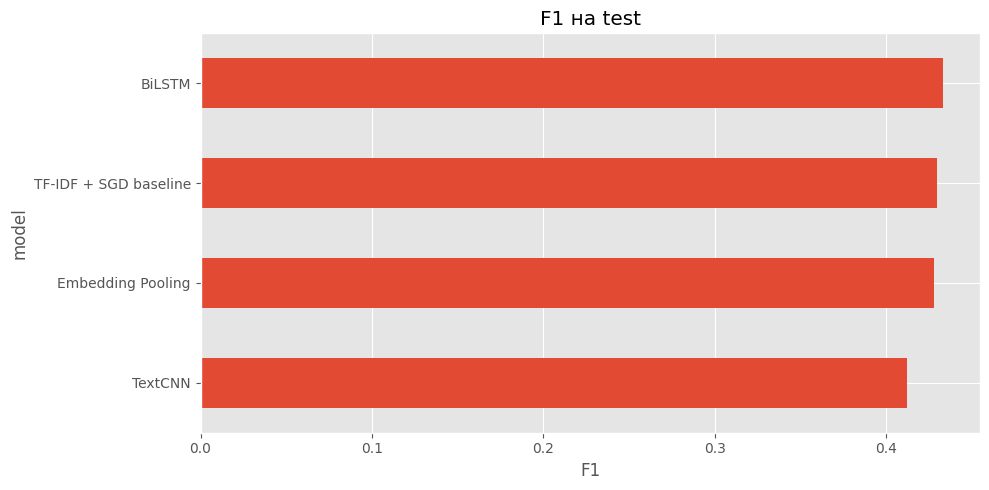

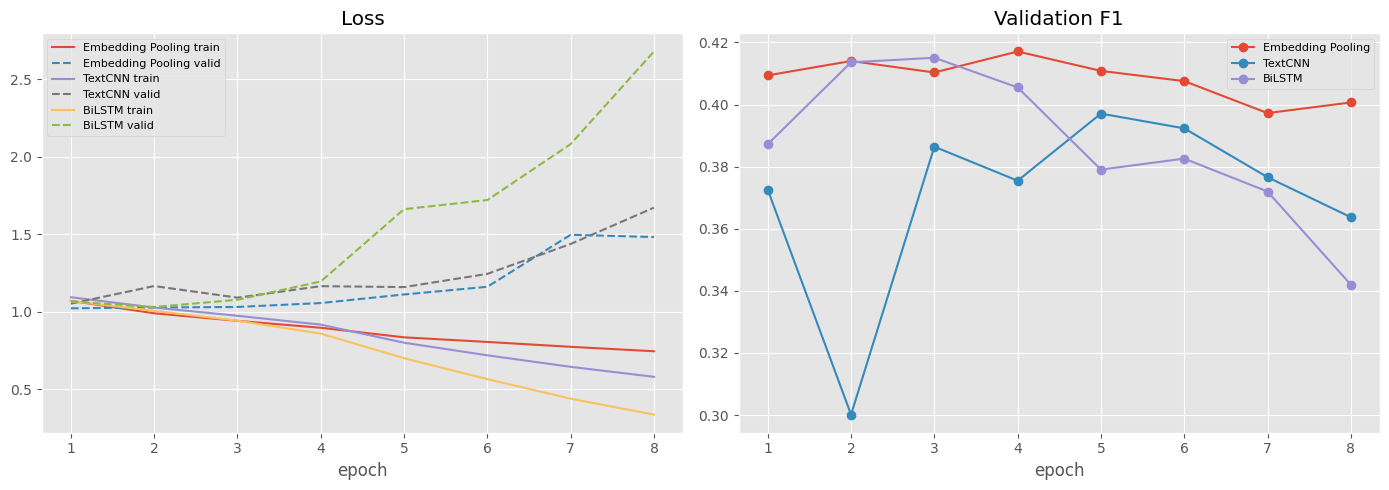

In [21]:
test_results = results_df[results_df['split'] == 'test'].copy()

fig, ax = plt.subplots(figsize=(10, 5))
test_results.sort_values('f1').plot(x='model', y='f1', kind='barh', ax=ax, legend=False)
ax.set_title('F1 на test')
ax.set_xlabel('F1')
plt.tight_layout()

if model_runs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, _, history, _ in model_runs:
        axes[0].plot(history['epoch'], history['train_loss'], label=f'{name} train')
        axes[0].plot(history['epoch'], history['valid_loss'], linestyle='--', label=f'{name} valid')
        axes[1].plot(history['epoch'], history['valid_f1'], marker='o', label=name)
    axes[0].set_title('Loss')
    axes[0].set_xlabel('epoch')
    axes[1].set_title('Validation F1')
    axes[1].set_xlabel('epoch')
    axes[0].legend(fontsize=8)
    axes[1].legend(fontsize=8)
    plt.tight_layout()
else:
    print('Графики обучения появятся после запуска нейросетевых моделей.')

## 11. Примеры предсказаний и сохранение итогов

В конце проверяю несколько предсказаний на тестовых объектах и сохраняю итоговые результаты. В папке `criterion4_outputs` остаются таблица сравнения моделей, краткое summary и артефакты обученных нейросетей, которые можно приложить к результатам проекта или использовать для повторной проверки.


In [22]:
def predict_proba(model, texts):
    model.eval()
    ids_list, lengths = [], []
    for text in texts:
        ids, length = encode_text(text)
        ids_list.append(ids)
        lengths.append(length)

    input_ids = torch.tensor(ids_list, dtype=torch.long).to(device)
    lengths = torch.tensor(lengths, dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_ids, lengths)
    return torch.sigmoid(logits).detach().cpu().numpy()


if not model_runs:
    raise ValueError('Для примеров предсказаний запустите хотя бы одну нейросетевую модель.')

best_model_name = test_results[test_results['model'].isin([run[0] for run in model_runs])].sort_values('f1', ascending=False).iloc[0]['model']
best_model = {name: model for name, model, _, _ in model_runs}[best_model_name]

sample = test_df[['name', 'tagline', 'description', 'text', 'success_score', 'target']].head(10).copy()
sample['pred_success_proba'] = predict_proba(best_model, sample['text'].tolist())
sample[['name', 'tagline', 'success_score', 'target', 'pred_success_proba']].sort_values(
    'pred_success_proba', ascending=False
)

,name,tagline,success_score,target,pred_success_proba
6,Rodeo by TwelveLabs,Describe your shot. Rodeo builds your first cut.,0.955873,1,0.653641
18,RingDisk,Brighten your video calls with different toned...,0.899382,1,0.651130
13,Maestro Deck,Open Maestro Studio alternative,0.542770,0,0.238384
38,Mediscanner,"Free, privacy-first symptom checker & live dis...",0.434602,0,0.140075
4,ForgeSpy,"AI detector for any link, photo, video, or voice",0.486692,0,0.129003
34,The Cookio,To make accurate cooking and baking accessible...,0.434602,0,0.100387
27,MixTool,"""200+ free tools. No signup. Nothing leaves yo...",0.434602,0,0.092738
30,AI Creator OS,"Plan, create & scale content faster with AI wo...",0.434602,0,0.087311
8,GlowPulse,Your Mac's camera is now a heart-rate sensor,0.917489,1,0.071575
32,6PM Hoodie,6pm Hoodie Online Shop in Germnay Get Upto 50%...,0.353483,0,0.034288


In [23]:
summary = {
    'target': 'successful_launch',
    'success_score_source': 'precomputed in CSV',
    'text_columns': [CFG.text_col],
    'n_rows': int(len(df)),
    'vocab_size': int(len(itos)),
    'best_test_model_by_f1': str(best_model_name),
    'threshold_note': 'threshold selected on validation by F1',
    'output_dir': str(OUTPUT_DIR),
    'artifacts': {name: artifact for name, _, _, artifact in model_runs},
}

summary_path = RESULTS_DIR / 'nlp_summary.json'
comparison_path = RESULTS_DIR / 'nlp_model_comparison.csv'

results_df.to_csv(comparison_path, index=False)
save_json(summary_path, summary)

if CFG.use_wandb and wandb is not None:
    run = start_wandb_run('Final summary', {'stage': 'summary'})
    wandb.log({'best_test_model_by_f1': best_model_name})
    log_wandb_artifact(run, comparison_path, 'nlp_model_comparison', 'results')
    log_wandb_artifact(run, summary_path, 'nlp_summary', 'results')
    run.finish()

summary


best_test_model_by_f1,BiLSTM


{'target': 'successful_launch',
 'success_score_source': 'precomputed in CSV',
 'text_columns': ['description'],
 'n_rows': 158581,
 'vocab_size': 20000,
 'best_test_model_by_f1': 'BiLSTM',
 'threshold_note': 'threshold selected on validation by F1',
 'output_dir': '/content/drive/MyDrive/GP5/criterion4_outputs',
 'artifacts': {'Embedding Pooling': '/content/drive/MyDrive/GP5/criterion4_outputs/artifacts/embedding_pooling/model.pt',
  'TextCNN': '/content/drive/MyDrive/GP5/criterion4_outputs/artifacts/textcnn/model.pt',
  'BiLSTM': '/content/drive/MyDrive/GP5/criterion4_outputs/artifacts/bilstm/model.pt'}}